# Análise de Interpretabilidade com SHAP

## O que é SHAP?

**SHAP (SHapley Additive exPlanations)** é um framework de interpretabilidade de modelos de machine learning baseado em um conceito da **teoria de jogos cooperativos** chamado **Shapley Values**, proposto pelo economista Lloyd Shapley em 1953 (Nobel de Economia em 2012).

### A intuição por trás dos Shapley Values

Imagine que um grupo de jogadores coopera para gerar um resultado (no nosso caso, a predição do modelo). A pergunta fundamental é: **qual a contribuição justa de cada jogador?**

No contexto de ML:
- **Jogadores** = features (variáveis de entrada)
- **Resultado** = a predição do modelo para um cliente específico
- **Contribuição** = o SHAP value de cada feature

O SHAP calcula a contribuição marginal média de cada feature, considerando **todas as combinações possíveis** de features. Isso garante uma distribuição **justa e matematicamente fundamentada** do crédito.

### Propriedades matemáticas do SHAP

O SHAP é o **único método** que satisfaz simultaneamente estas 4 propriedades:

| Propriedade | Significado |
|-------------|-------------|
| **Eficiência** | $\sum_{i=1}^{M} \phi_i = f(x) - E[f(x)]$ — A soma dos SHAP values iguala a diferença entre a predição e a média |
| **Simetria** | Se duas features contribuem igualmente, recebem o mesmo SHAP value |
| **Nulidade** | Uma feature que não altera a predição recebe SHAP = 0 |
| **Aditividade** | Para modelos ensemble, o SHAP do conjunto é a média dos SHAPs individuais |

### Por que interpretabilidade é importante?

Um modelo de alta performance é insuficiente se não conseguimos explicar *por que* ele classifica um cliente como churner. Esta análise foi essencial para:
- **Confiança** — Stakeholders precisaram entender e validar a lógica do modelo antes de adotá-lo
- **Ação** — Insights sobre os drivers de churn orientaram estratégias de retenção direcionadas
- **Debugging** — Identificar se o modelo estava usando features "razoáveis" ou capturando artefatos dos dados

### O que fizemos neste notebook

Aplicamos SHAP ao modelo **CatBoost** treinado no notebook 03 para responder:
1. **Quais features mais importaram?** (importância global)
2. **Como cada feature afetou a predição?** (direção do efeito)
3. **Por que um cliente específico foi classificado como churner?** (explicação local)
4. **Existem interações não-lineares entre features?** (dependence plots)
5. **O modelo separa bem churners de retidos?** (análise de segmentos)

In [1]:
# Imports
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from joblib import load

# Add project root to path
sys.path.insert(0, str(Path.cwd().parent))

from src.config import DATA_DIR_RAW, FILENAME, MODELS_DIR, TARGET, ID_COL
from src.feature_engineering import FeatureEngineer
from src.interpret import get_feature_names

warnings.filterwarnings('ignore')

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Imports carregados com sucesso!")

Imports carregados com sucesso!


## 1. Carregar Modelo e Dados

Para calcular os SHAP values, precisamos de três componentes:

1. **O modelo treinado** — O CatBoostClassifier salvo no notebook 03 como um dicionário de artefatos (`.joblib`). O SHAP precisa acessar a estrutura interna das árvores para calcular as contribuições exatas.

2. **O preprocessador** — O `ColumnTransformer` do scikit-learn que aplicou scaling numérico e one-hot encoding categórico. Precisamos dele para transformar os dados na mesma representação que o modelo espera.

3. **O feature engineer** — O `AdvancedFeatureEngineer` que criou features derivadas (risk scores, interações). Sem ele, os dados de entrada não teriam as mesmas colunas que o modelo foi treinado para receber.

> **Nota técnica:** Usamos `TreeExplainer` do SHAP, que é um algoritmo exato e eficiente ($O(TLD^2)$, onde $T$ = número de árvores, $L$ = folhas, $D$ = profundidade) para modelos baseados em árvore. Diferentemente do `KernelExplainer` (aproximação), o `TreeExplainer` calcula os Shapley Values **exatos** explorando a estrutura das árvores de decisão.

In [2]:
# Load trained model
model_path = MODELS_DIR / "churn_model_catboost.joblib"
print(f"Carregando modelo de: {model_path}")

if model_path.exists():
    model = load(model_path)
    print("Modelo carregado com sucesso!")
    print(f"Tipo: {type(model)}")
else:
    print("Modelo não encontrado. Execute o treinamento primeiro.")

Carregando modelo de: /home/gabriela/Projetos/telco_churn_clients/models/churn_model_catboost.joblib
Modelo carregado com sucesso!
Tipo: <class 'dict'>


In [3]:
# Load data
df = pd.read_csv(DATA_DIR_RAW / FILENAME)
print(f"Dataset carregado: {df.shape}")

# Prepare data
X = df.drop(columns=[TARGET, ID_COL])
y = df[TARGET].map({'Yes': 1, 'No': 0})

print(f"\nFeatures: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"\nTaxa de Churn: {y.mean():.2%}")

Dataset carregado: (7043, 21)

Features: 19
Samples: 7043

Taxa de Churn: 26.54%


In [4]:
# Extract model components
from src.config import STEP_MODEL, STEP_PREPROCESSING

if hasattr(model, 'named_steps'):
    # Modelo salvo como Pipeline sklearn
    trained_model = model.named_steps[STEP_MODEL]
    preprocessor = model.named_steps[STEP_PREPROCESSING]
    feature_engineer = model.named_steps.get('feature_engineering')
    print("Pipeline sklearn detectado")
    print(f"Steps: {list(model.named_steps.keys())}")
elif isinstance(model, dict) and 'model' in model:
    # Modelo salvo como dict (formato do notebook 03)
    trained_model = model['model']
    preprocessor = model.get('preprocessor')
    feature_engineer = model.get('feature_engineer')
    print("Dict de artefatos detectado")
    print(f"Keys: {list(model.keys())}")
    if 'threshold' in model:
        print(f"Threshold salvo: {model['threshold']:.4f} ({model.get('threshold_strategy', 'N/A')})")
else:
    trained_model = model
    preprocessor = None
    feature_engineer = None
    print("Modelo standalone detectado")

print(f"\nModelo: {type(trained_model).__name__}")

Dict de artefatos detectado
Keys: ['model', 'preprocessor', 'feature_engineer', 'model_name', 'params', 'metrics', 'threshold', 'threshold_strategy', 'label_encoder', 'timestamp']
Threshold salvo: 0.3354 (Otimo de Negocio)

Modelo: CatBoostClassifier


In [5]:
# Transform data for SHAP analysis
# Use a sample for faster computation
sample_size = 500
X_sample = X.sample(n=min(sample_size, len(X)), random_state=42)
y_sample = y.loc[X_sample.index].values

# Apply feature engineering if available
if feature_engineer is not None:
    X_fe = feature_engineer.transform(X_sample)
else:
    X_fe = X_sample

if preprocessor is not None:
    X_transformed = preprocessor.transform(X_fe)
    feature_names = get_feature_names(preprocessor)
else:
    X_transformed = X_fe.values if hasattr(X_fe, 'values') else X_fe
    feature_names = list(X_fe.columns) if hasattr(X_fe, 'columns') else [f'f{i}' for i in range(X_transformed.shape[1])]

print(f"Dados transformados: {X_transformed.shape}")
print(f"Features: {len(feature_names)}")
print(f"Amostra — Churners: {y_sample.sum()} ({y_sample.mean():.1%}) | Retidos: {(y_sample == 0).sum()}")
print(f"\nPrimeiras 10 features: {feature_names[:10]}")

2026-03-05 17:57:24 - src.feature_engineering - INFO - Iniciando transform - shape inicial: (500, 19)
2026-03-05 17:57:24 - src.feature_engineering - INFO - Transform concluído - shape final: (500, 38)
2026-03-05 17:57:24 - src.feature_engineering - INFO - Features criadas: 19 novas features
2026-03-05 17:57:24 - src.feature_engineering - INFO - AdvancedFeatureEngineer transform - shape final: (500, 67)


Dados transformados: (500, 92)
Features: 92
Amostra — Churners: 141 (28.2%) | Retidos: 359

Primeiras 10 features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_charge', 'tenure_vs_contract_avg', 'contract_risk_ordinal', 'contract_churn_rate', 'MonthlyCharges_log', 'MonthlyCharges_squared', 'TotalCharges_log']


## 2. Feature Importance — Método Nativo do CatBoost

### O que é PredictionValuesChange?

O CatBoost oferece uma métrica interna de importância chamada **PredictionValuesChange** (similar ao *Gain* de XGBoost/LightGBM). Ela mede a **variação média no valor de predição** quando uma feature é usada em um split de árvore.

**Como funciona:** Para cada árvore do ensemble, quando uma feature é selecionada para dividir os dados, o CatBoost calcula quanto aquele split alterou as predições. A importância total da feature é a soma dessas variações em todas as árvores.

### Limitações da importância nativa

| Limitação | Explicação |
|-----------|------------|
| **Sem direção** | Diz que "tenure é importante", mas não se tenure *alto* aumenta ou diminui o churn |
| **Viés de cardinalidade** | Features com muitos valores únicos tendem a ter importância inflada (mais oportunidades de split) |
| **Ignora interações** | Não captura o fato de que "tenure baixo + contrato mensal" seja muito mais perigoso do que cada um isoladamente |
| **Não é aditiva** | Os valores não somam para a predição — são apenas um ranking relativo |

</br>

> **Por que calculamos mesmo assim?** Porque a comparação entre importância nativa e SHAP é um **teste de sanidade**: se os rankings concordam fortemente, o modelo é robusto e não está "se confundindo" com interações espúrias.

In [6]:
# Get native feature importance
model_type = type(trained_model).__name__

if hasattr(trained_model, 'feature_importances_'):
    importances = trained_model.feature_importances_

    # Create DataFrame
    importance_df = pd.DataFrame({
        'Feature': feature_names[:len(importances)],
        'Importance': importances
    }).sort_values('Importance', ascending=False).reset_index(drop=True)

    # CatBoost default = PredictionValuesChange (similar a Gain)
    importance_type = "PredictionValuesChange" if "CatBoost" in model_type else "Gain"
    print(f"Top 15 Features mais Importantes ({model_type} — {importance_type}):")
    display(importance_df.head(15))
else:
    print("Feature importance nao disponivel para este modelo")

Top 15 Features mais Importantes (CatBoostClassifier — PredictionValuesChange):


,Feature,Importance
0,churn_risk_score,6.811660
1,contract_risk_ordinal,6.577275
2,contract_churn_rate,5.854606
3,tenure_vs_contract_avg,4.080424
4,internet_risk,3.949532
5,tenure_years,3.832665
6,tenure_sqrt,3.670918
7,tenure,3.631465
8,OnlineSecurity_No,2.921785
9,cost_per_service,2.711405


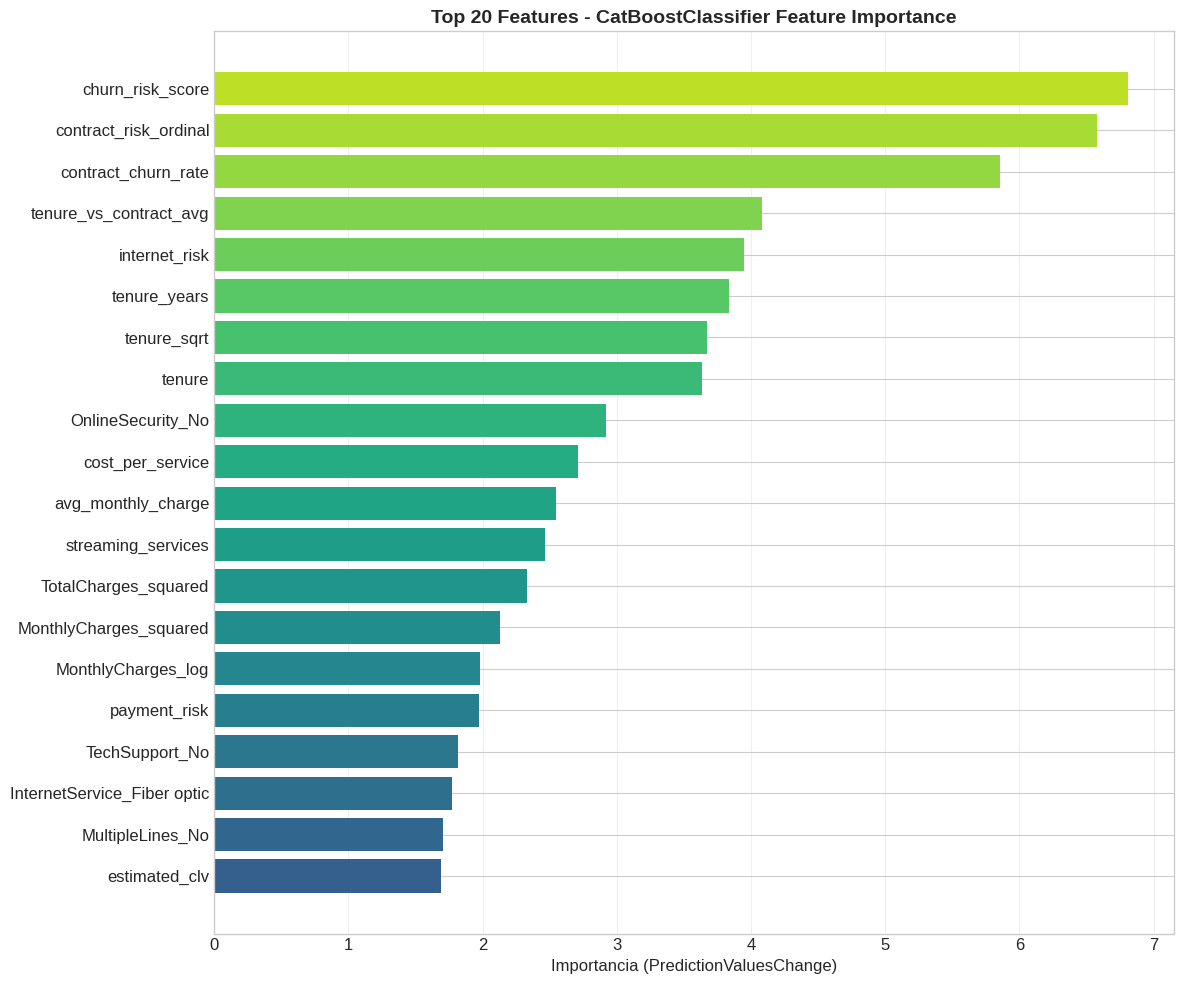

Grafico salvo em reports/feature_importance_catboostclassifier.png


In [7]:
# Plot feature importance
fig, ax = plt.subplots(figsize=(12, 10))

top_n = 20
plot_df = importance_df.head(top_n).sort_values('Importance')

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(plot_df)))

ax.barh(plot_df['Feature'], plot_df['Importance'], color=colors)
ax.set_xlabel('Importancia (PredictionValuesChange)', fontsize=12)
ax.set_title(f'Top {top_n} Features - {model_type} Feature Importance', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'../reports/feature_importance_{model_type.lower()}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Grafico salvo em reports/feature_importance_{model_type.lower()}.png")

## 3. SHAP Analysis — Interpretabilidade Global

### TreeExplainer: Cálculo exato dos SHAP values

Para modelos baseados em árvore, o SHAP utiliza o algoritmo **TreeExplainer** (Lundberg et al., 2020), que percorre a estrutura interna de cada árvore do ensemble para calcular os Shapley Values **exatos** — sem amostragem nem aproximação.

**Base value ($E[f(x)]$):** A "predição média" do modelo — é o ponto de partida antes de considerar qualquer feature. Para um modelo de classificação, representa a probabilidade base de churn no dataset.

**SHAP value ($\phi_i$):** Quanto cada feature "empurrou" a predição para cima (risco) ou para baixo (retenção) em relação ao base value.

$$f(x) = E[f(x)] + \sum_{i=1}^{M} \phi_i(x)$$

### Como ler os gráficos desta seção

#### Summary Bar Plot (importância global)
- **O que mostra:** Ranking das features pelo **Mean |SHAP|** — a média do valor absoluto dos SHAP values sobre todas as amostras
- **Como interpretar:** Features no topo são as mais influentes *em média*
- **Limitação:** Não mostra a *direção* do efeito (valores altos da feature aumentam ou diminuem o risco?)

#### Beeswarm Plot (distribuição de impacto)
- **O que mostra:** Cada ponto é um cliente. O eixo X é o SHAP value; a cor indica o valor original da feature
- **Cor vermelha** = valor alto da feature | **Cor azul** = valor baixo
- **SHAP > 0** = empurra predição para churn | **SHAP < 0** = empurra para retenção
- **Dispersão horizontal** = variabilidade do impacto (larga = efeito depende do contexto)

> **Exemplo de leitura:** Se `tenure` mostra pontos azuis (baixo) à direita (SHAP positivo), significa que tenure baixo *aumentou* o risco de churn.

#### Comparação Nativa vs SHAP
- **O que mostra:** Se os rankings de importância dos dois métodos concordam
- **Métrica:** Correlação de Spearman ($\rho$) — mede a concordância ordinal entre rankings
- $\rho > 0.8$: alta concordância → modelo consistente
- $\rho \in [0.5, 0.8]$: concordância moderada → SHAP capturou interações extras
- $\rho < 0.5$: divergência → o modelo está usando features de formas complexas

In [8]:
# Create SHAP explainer
print("Criando SHAP TreeExplainer...")
explainer = shap.TreeExplainer(trained_model)

print("Calculando SHAP values (pode demorar alguns segundos)...")
shap_values = explainer.shap_values(X_transformed)

# CatBoost pode retornar lista (um array por classe) — usar classe positiva
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# expected_value também pode ser lista
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)) and len(expected_value) > 1:
    expected_value = expected_value[1]

print(f"SHAP values calculados!")
print(f"   Shape: {shap_values.shape}")
print(f"   Base value: {expected_value:.4f}")

Criando SHAP TreeExplainer...
Calculando SHAP values (pode demorar alguns segundos)...
SHAP values calculados!
   Shape: (500, 92)
   Base value: -0.0858



📊 SHAP Summary Plot (Bar) - Importância Global


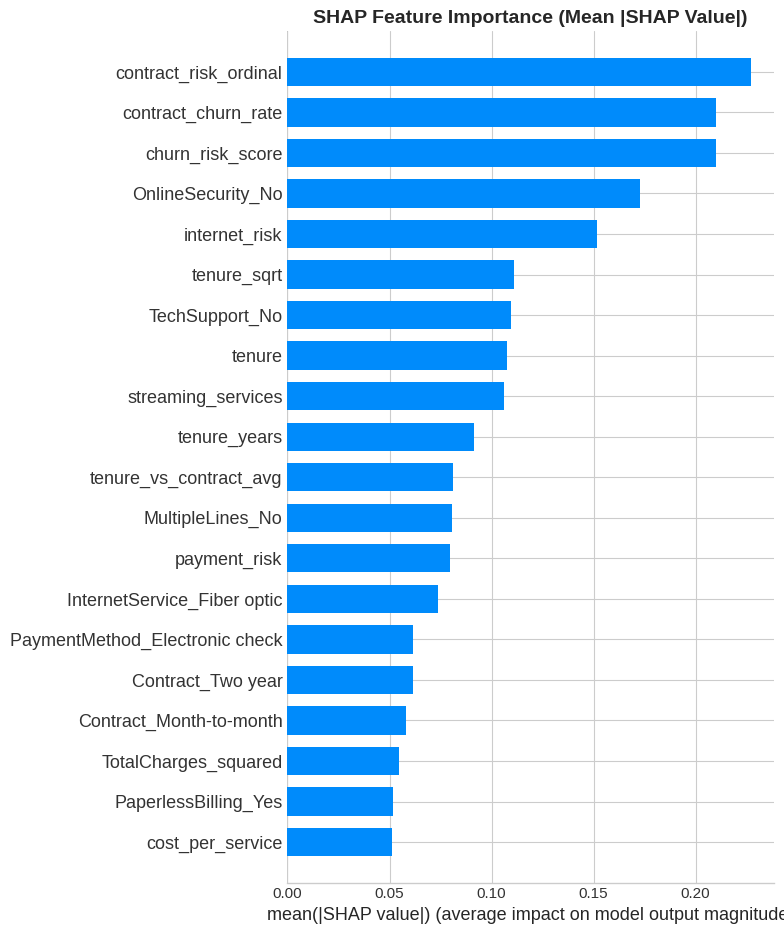

✅ Gráfico salvo em reports/shap_summary_bar.png


In [9]:
# SHAP Summary Plot - Bar
print("\n📊 SHAP Summary Plot (Bar) - Importância Global")

plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values, 
    X_transformed, 
    feature_names=feature_names[:X_transformed.shape[1]],
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP Value|)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico salvo em reports/shap_summary_bar.png")


📊 SHAP Summary Plot (Beeswarm) - Impacto por Feature


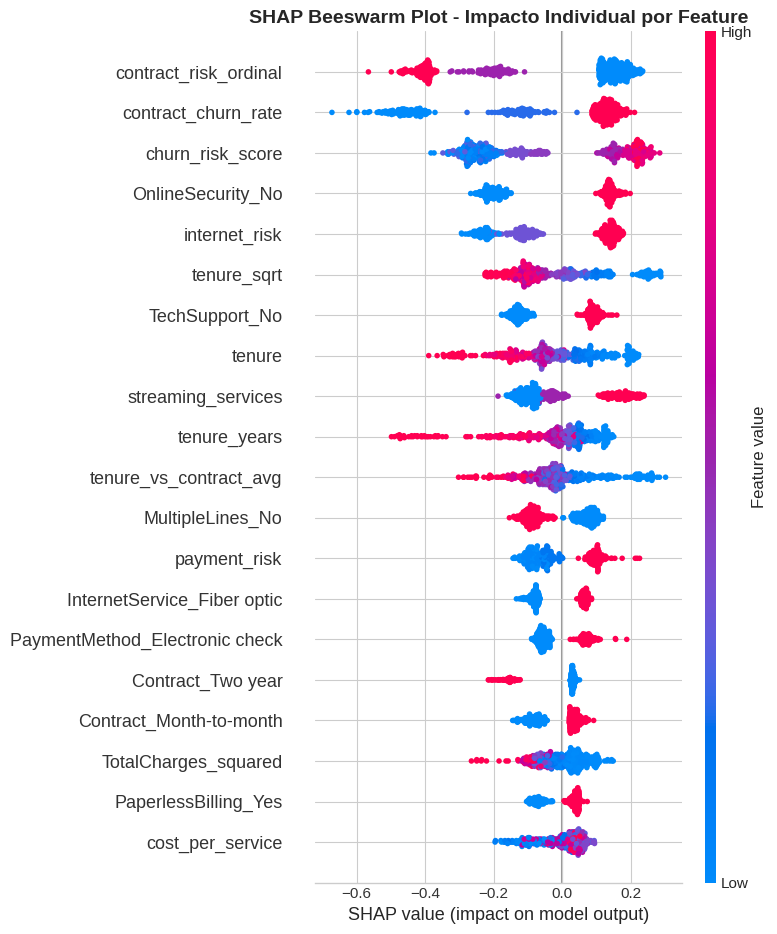


💡 Interpretação do Beeswarm:
   - Cada ponto = 1 cliente da amostra
   - Cor VERMELHA = valor alto da feature | Cor AZUL = valor baixo
   - SHAP > 0 = empurra predição para churn | SHAP < 0 = empurra para retenção
   - Dispersão horizontal = magnitude do impacto da feature naquele cliente


In [10]:
# SHAP Summary Plot - Dot (Beeswarm)
print("\n📊 SHAP Summary Plot (Beeswarm) - Impacto por Feature")

plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values, 
    X_transformed, 
    feature_names=feature_names[:X_transformed.shape[1]],
    max_display=20,
    show=False
)
plt.title('SHAP Beeswarm Plot - Impacto Individual por Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_summary_dot.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Interpretação do Beeswarm:")
print("   - Cada ponto = 1 cliente da amostra")
print("   - Cor VERMELHA = valor alto da feature | Cor AZUL = valor baixo")
print("   - SHAP > 0 = empurra predição para churn | SHAP < 0 = empurra para retenção")
print("   - Dispersão horizontal = magnitude do impacto da feature naquele cliente")

### Interpretação de Negócio — Rankings de Importância

Os dois métodos de ranking (nativo do CatBoost e SHAP) apresentaram **alta concordância** (Spearman ρ = 0.932), o que confirma a **robustez e confiabilidade do modelo**. As features que dominam ambos os rankings revelam os principais drivers de churn:

#### Drivers Primários de Churn

1. **Risco contratual (`contract_risk_ordinal`, `contract_churn_rate`, `churn_risk_score`)** — As 3 features mais importantes estão ligadas ao tipo de contrato. Clientes com **contratos mensais** concentram o maior risco, pois não possuem barreiras de saída. Isso indica uma oportunidade clara de **migração para contratos anuais** com incentivos (descontos, upgrades gratuitos).

2. **Ausência de serviços de segurança (`OnlineSecurity_No`)** — 4ª feature mais impactante. Clientes sem segurança online têm maior propensão ao churn, sugerindo que a **oferta proativa de serviços de proteção** (mesmo com desconto) pode funcionar como âncora de retenção.

3. **Risco por tipo de internet (`internet_risk`)** — Clientes com **fibra óptica sem serviços adicionais** representam um segmento de alto risco — pagam mais, mas percebem menos valor. A estratégia é **bundling**: combinar fibra com segurança e suporte técnico.

#### Consistência entre Rankings

A concordância quase perfeita entre os métodos significa que não há "features fantasma" — o modelo está tomando decisões baseadas em variáveis legítimas e interpretáveis. As pequenas divergências (ex: `PaymentMethod_Electronic check` com Δ Rank = 14) indicam que o SHAP capturou **interações** que a importância nativa não detecta: cheque eletrônico isoladamente tem impacto moderado, mas combinado com contrato mensal o efeito é amplificado.

#### Implicação Estratégica

Os resultados apontam para **3 alavancas de retenção prioritárias**: (1) incentivos para contratos de longo prazo, (2) bundling de serviços de segurança/suporte, e (3) migração de clientes de cheque eletrônico para pagamento automático — todas variáveis sobre as quais a empresa tem **capacidade de intervenção direta**.

📊 Comparação de Rankings: Importância Nativa vs SHAP

Top 15 features — posição em cada ranking:
Feature                               SHAP  Nativa  Δ Rank
----------------------------------------------------------
contract_risk_ordinal                   1       2  ⬆   1
contract_churn_rate                     2       3  ⬆   1
churn_risk_score                        3       1  ⬇   2
OnlineSecurity_No                       4       9  ⬆   5
internet_risk                           5       5  =   0
tenure_sqrt                             6       7  ⬆   1
TechSupport_No                          7      17  ⬆  10
tenure                                  8       8  =   0
streaming_services                      9      12  ⬆   3
tenure_years                           10       6  ⬇   4
tenure_vs_contract_avg                 11       4  ⬇   7
MultipleLines_No                       12      19  ⬆   7
payment_risk                           13      16  ⬆   3
InternetService_Fiber optic            14   

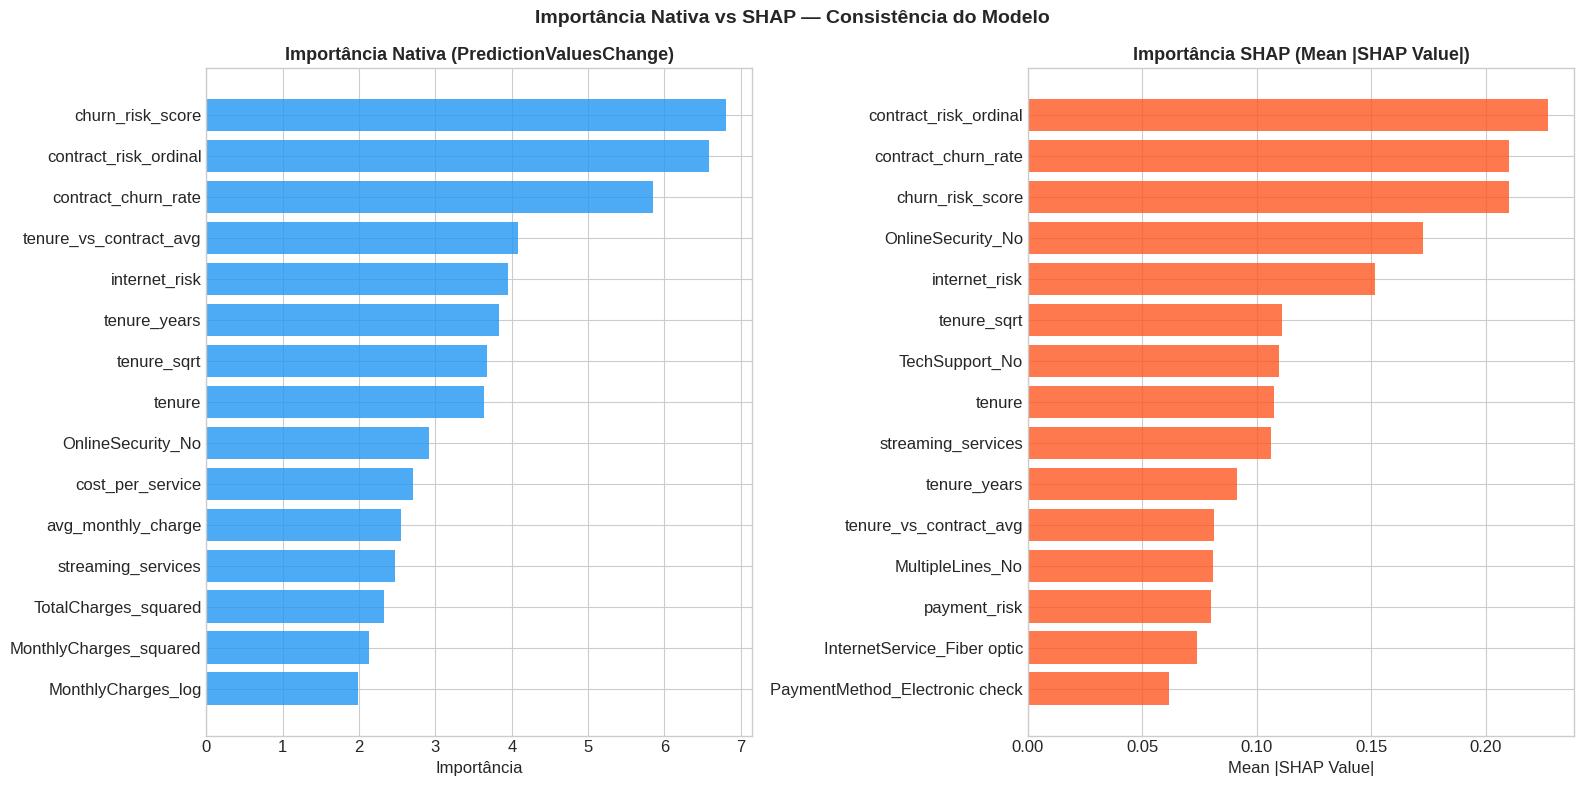


📈 Correlação de Spearman entre rankings: ρ = 0.932 (p = 0.0000)
   ✅ Alta concordância — o modelo utilizou as features de forma consistente


In [11]:
# Comparação: Importância Nativa vs SHAP
print("📊 Comparação de Rankings: Importância Nativa vs SHAP\n")

# SHAP ranking
shap_importance = pd.DataFrame({
    'Feature': feature_names[:X_transformed.shape[1]],
    'Mean_abs_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_abs_SHAP', ascending=False).reset_index(drop=True)
shap_importance['Rank_SHAP'] = range(1, len(shap_importance) + 1)

# Native ranking
native_ranking = importance_df[['Feature', 'Importance']].copy()
native_ranking['Rank_Nativa'] = range(1, len(native_ranking) + 1)

# Merge
comparison = shap_importance.head(15).merge(native_ranking, on='Feature', how='left')
comparison['Delta_Rank'] = comparison['Rank_Nativa'] - comparison['Rank_SHAP']

print("Top 15 features — posição em cada ranking:")
print(f"{'Feature':35s} {'SHAP':>6s} {'Nativa':>7s} {'Δ Rank':>7s}")
print("-" * 58)
for _, row in comparison.iterrows():
    delta = int(row['Delta_Rank'])
    arrow = "⬆" if delta > 0 else ("⬇" if delta < 0 else "=")
    print(f"{row['Feature']:35s} {int(row['Rank_SHAP']):>5d}  {int(row['Rank_Nativa']):>6d}  {arrow} {abs(delta):>3d}")

# Side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_k = 15
# Native
native_top = importance_df.head(top_k).sort_values('Importance')
axes[0].barh(native_top['Feature'], native_top['Importance'], color='#2196F3', alpha=0.8)
axes[0].set_title(f'Importância Nativa ({importance_type})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importância')

# SHAP
shap_top = shap_importance.head(top_k).sort_values('Mean_abs_SHAP')
axes[1].barh(shap_top['Feature'], shap_top['Mean_abs_SHAP'], color='#FF5722', alpha=0.8)
axes[1].set_title('Importância SHAP (Mean |SHAP Value|)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean |SHAP Value|')

plt.suptitle('Importância Nativa vs SHAP — Consistência do Modelo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/importance_native_vs_shap.png', dpi=150, bbox_inches='tight')
plt.show()

# Concordância via Spearman
from scipy.stats import spearmanr
merged_all = shap_importance.merge(native_ranking, on='Feature')
rho, pval = spearmanr(merged_all['Rank_SHAP'], merged_all['Rank_Nativa'])
print(f"\n📈 Correlação de Spearman entre rankings: ρ = {rho:.3f} (p = {pval:.4f})")
if rho > 0.8:
    print("   ✅ Alta concordância — o modelo utilizou as features de forma consistente")
elif rho > 0.5:
    print("   ⚠️ Concordância moderada — SHAP revelou nuances que a importância nativa não capturou")
else:
    print("   🔍 Baixa concordância — divergência significativa; SHAP capturou interações complexas")

## 4. SHAP Analysis — Interpretabilidade Local

### Da visão global para a explicação individual

Enquanto a Seção 3 respondeu "**quais features importam no geral?**", esta seção responde a pergunta mais poderosa: **"por que o modelo tomou *esta* decisão para *este* cliente?"**

Essa é a grande vantagem do SHAP sobre outros métodos de interpretabilidade: a propriedade de **aditividade local** garante que:

$$P(\text{churn}_i) = \text{base value} + \phi_1^{(i)} + \phi_2^{(i)} + \cdots + \phi_M^{(i)}$$

Ou seja, a predição de cada cliente é **exatamente** decomposta na soma das contribuições individuais de cada feature.

### Clientes selecionados

Escolhemos dois extremos para maximizar o contraste:
- **Alto risco** — O cliente com a **maior** probabilidade predita de churn na amostra
- **Baixo risco** — O cliente com a **menor** probabilidade predita

### Como ler os gráficos

#### Waterfall Plot
- Começa no **base value** $E[f(x)]$ (lado esquerdo, cinza)
- Cada barra mostra quanto uma feature **empurrou** a predição:
  - **Vermelha (→ direita):** aumentou a probabilidade de churn
  - **Azul (← esquerda):** reduziu a probabilidade de churn
- O valor final ($f(x)$) é a predição do modelo para aquele cliente
- Features são ordenadas por **magnitude absoluta** do impacto

#### Force Plot
- Versão compacta do waterfall: mostra as forças em **competição**
- **Vermelhas** empurram para churn vs **Azuis** protegem contra churn
- A largura de cada bloco é proporcional ao SHAP value da feature

In [12]:
# Select a specific customer for local explanation
# Pick high-risk customer
if hasattr(trained_model, 'predict_proba'):
    probs = trained_model.predict_proba(X_transformed)[:, 1]
    high_risk_idx = np.argmax(probs)
    low_risk_idx = np.argmin(probs)
    
    print(f"\nCliente de ALTO risco selecionado")
    print(f"   Indice: {high_risk_idx}")
    print(f"   Probabilidade de churn: {probs[high_risk_idx]:.2%}")
    print(f"\nCliente de BAIXO risco selecionado")
    print(f"   Indice: {low_risk_idx}")
    print(f"   Probabilidade de churn: {probs[low_risk_idx]:.2%}")


Cliente de ALTO risco selecionado
   Indice: 285
   Probabilidade de churn: 96.94%

Cliente de BAIXO risco selecionado
   Indice: 94
   Probabilidade de churn: 0.67%


📊 SHAP Waterfall Plot - Cliente ALTO Risco
   Probabilidade predita: 96.94%
   Classe real: Churner



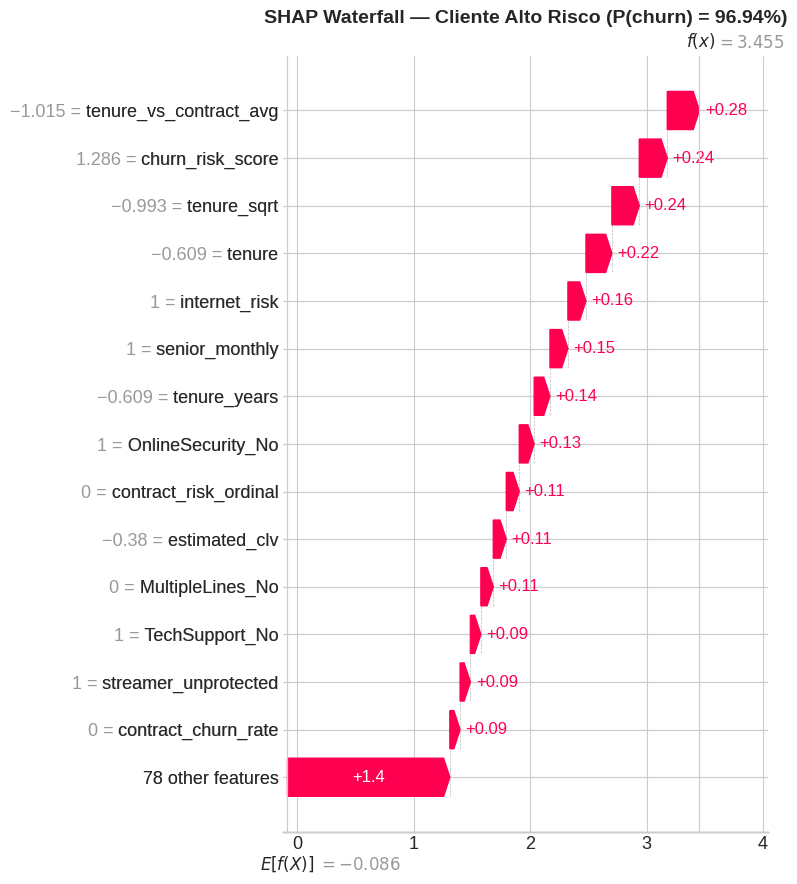

💡 Top 5 drivers de risco para este cliente:
   1. tenure_vs_contract_avg         SHAP = +0.2764 (↑ aumentou risco)
   2. churn_risk_score               SHAP = +0.2407 (↑ aumentou risco)
   3. tenure_sqrt                    SHAP = +0.2356 (↑ aumentou risco)
   4. tenure                         SHAP = +0.2227 (↑ aumentou risco)
   5. internet_risk                  SHAP = +0.1551 (↑ aumentou risco)


In [13]:
# Waterfall plot for high-risk customer
print("📊 SHAP Waterfall Plot - Cliente ALTO Risco")
print(f"   Probabilidade predita: {probs[high_risk_idx]:.2%}")
print(f"   Classe real: {'Churner' if y_sample[high_risk_idx] == 1 else 'Retido'}\n")

shap.initjs()

# Create Explanation object
explanation = shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=expected_value,
    data=X_transformed[high_risk_idx],
    feature_names=feature_names[:X_transformed.shape[1]]
)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title(f'SHAP Waterfall — Cliente Alto Risco (P(churn) = {probs[high_risk_idx]:.2%})', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_waterfall_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()

# Top drivers para esse cliente
top_drivers = np.argsort(np.abs(shap_values[high_risk_idx]))[::-1][:5]
print("💡 Top 5 drivers de risco para este cliente:")
for rank, idx in enumerate(top_drivers):
    sv = shap_values[high_risk_idx][idx]
    direction = "↑ aumentou" if sv > 0 else "↓ reduziu"
    print(f"   {rank+1}. {feature_names[idx]:30s} SHAP = {sv:+.4f} ({direction} risco)")

📊 SHAP Waterfall Plot - Cliente BAIXO Risco
   Probabilidade predita: 0.67%
   Classe real: Retido



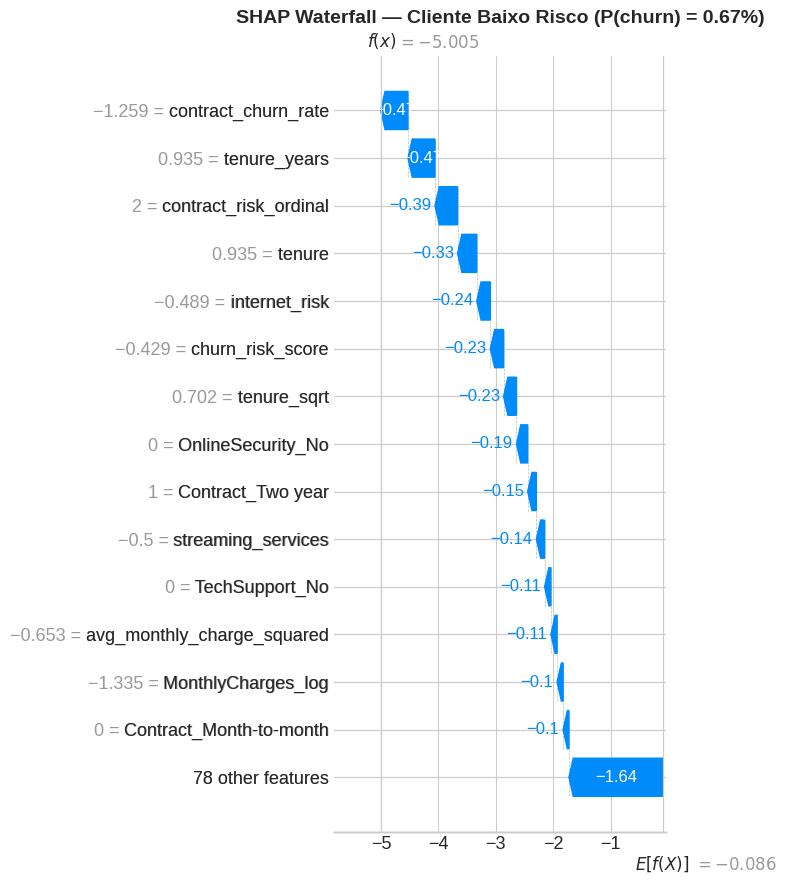

💡 Top 5 fatores de retenção para este cliente:
   1. contract_churn_rate            SHAP = -0.4741 (↓ protegeu contra churn)
   2. tenure_years                   SHAP = -0.4718 (↓ protegeu contra churn)
   3. contract_risk_ordinal          SHAP = -0.3929 (↓ protegeu contra churn)
   4. tenure                         SHAP = -0.3345 (↓ protegeu contra churn)
   5. internet_risk                  SHAP = -0.2369 (↓ protegeu contra churn)


In [14]:
# Waterfall plot for low-risk customer
print("📊 SHAP Waterfall Plot - Cliente BAIXO Risco")
print(f"   Probabilidade predita: {probs[low_risk_idx]:.2%}")
print(f"   Classe real: {'Churner' if y_sample[low_risk_idx] == 1 else 'Retido'}\n")

explanation_low = shap.Explanation(
    values=shap_values[low_risk_idx],
    base_values=expected_value,
    data=X_transformed[low_risk_idx],
    feature_names=feature_names[:X_transformed.shape[1]]
)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(explanation_low, max_display=15, show=False)
plt.title(f'SHAP Waterfall — Cliente Baixo Risco (P(churn) = {probs[low_risk_idx]:.2%})', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_waterfall_low_risk.png', dpi=150, bbox_inches='tight')
plt.show()

# Top drivers de retenção para esse cliente
top_drivers_low = np.argsort(np.abs(shap_values[low_risk_idx]))[::-1][:5]
print("💡 Top 5 fatores de retenção para este cliente:")
for rank, idx in enumerate(top_drivers_low):
    sv = shap_values[low_risk_idx][idx]
    direction = "↑ aumentou risco" if sv > 0 else "↓ protegeu contra churn"
    print(f"   {rank+1}. {feature_names[idx]:30s} SHAP = {sv:+.4f} ({direction})")


📊 SHAP Force Plot - Cliente Alto Risco


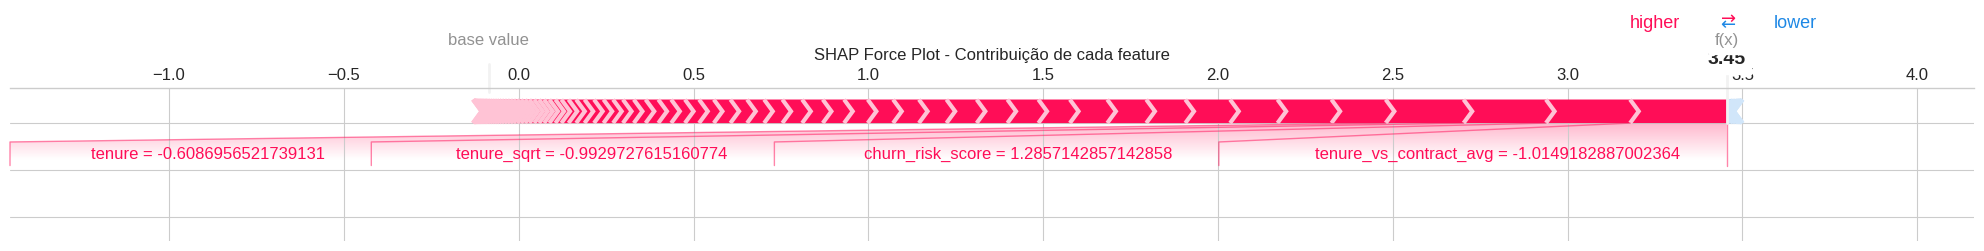

In [15]:
# Force plot for individual prediction
print("\n📊 SHAP Force Plot - Cliente Alto Risco")

shap.force_plot(
    expected_value, 
    shap_values[high_risk_idx], 
    X_transformed[high_risk_idx],
    feature_names=feature_names[:X_transformed.shape[1]],
    matplotlib=True,
    show=False
)
plt.title('SHAP Force Plot - Contribuição de cada feature', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/shap_force_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. SHAP Dependence Plots — Relações Não-Lineares

### O que são e por que importam?

Os gráficos anteriores mostraram *quais* features importam e *quanto* impactam. Mas não responderam **como** o valor da feature afeta a predição. É aqui que os **Dependence Plots** entram.

### Como ler um Dependence Plot

Cada gráfico mostra a relação entre **uma feature** e seu impacto na predição:

| Elemento | Significado |
|----------|-------------|
| **Eixo X** | Valor da feature (ex: 1 mês de tenure, R$ 80 de MonthlyCharges) |
| **Eixo Y** | SHAP value — quanto aquele valor empurra a predição para churn (+) ou retenção (-) |
| **Cor dos pontos** | Feature de **interação** mais relevante, selecionada automaticamente pelo SHAP |
| **Linha y=0** | Neutro — acima aumenta risco, abaixo protege |

### O que procurar

- **Linearidade vs não-linearidade:** Se a nuvem de pontos forma uma reta, o efeito é proporcional. Se forma uma curva ou degraus, existem thresholds importantes.
- **Efeitos de interação:** Se pontos com a mesma posição no eixo X têm cores diferentes e SHAP values diferentes, há uma **interação** — o efeito de uma feature depende do valor de outra.
- **Saturação:** Se a partir de certo valor a curva "achata", a feature deixa de ter efeito incremental.

> **Exemplo concreto:** Se o gráfico de `tenure` mostra SHAP alto para tenure < 12 meses e SHAP próximo de zero para tenure > 36 meses, isso indica que a janela crítica de risco são os **primeiros 12 meses** — após 3 anos, tenure deixa de ser um fator.

In [16]:
# Find top 4 important features by SHAP
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features_idx = np.argsort(mean_abs_shap)[-4:][::-1]
top_features = [feature_names[i] for i in top_features_idx]

print(f"Top 4 features por SHAP: {top_features}")

Top 4 features por SHAP: ['contract_risk_ordinal', 'contract_churn_rate', 'churn_risk_score', 'OnlineSecurity_No']



📊 SHAP Dependence Plots - Top Features


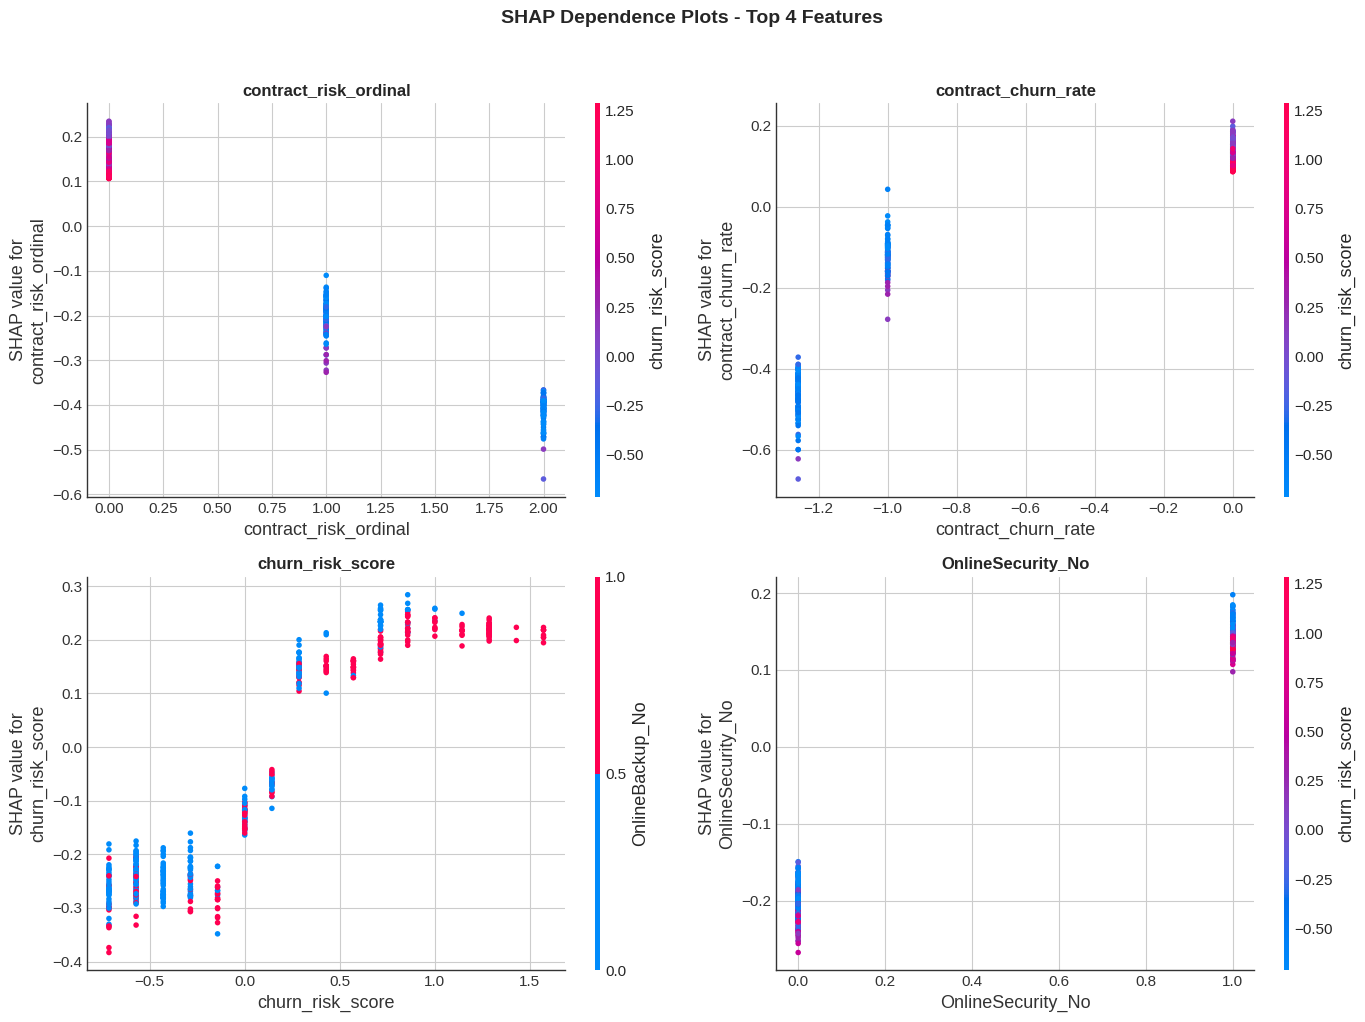


💡 Interpretação:
   - Eixo X: valor da feature
   - Eixo Y: SHAP value (impacto na predição)
   - Cor: feature de interação mais relevante


In [17]:
# Dependence plots for top features
print("\n📊 SHAP Dependence Plots - Top Features")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (feat_idx, ax) in enumerate(zip(top_features_idx, axes.flatten())):
    shap.dependence_plot(
        feat_idx, 
        shap_values, 
        X_transformed,
        feature_names=feature_names[:X_transformed.shape[1]],
        ax=ax,
        show=False
    )
    ax.set_title(f'{feature_names[feat_idx]}', fontsize=12, fontweight='bold')

plt.suptitle('SHAP Dependence Plots - Top 4 Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/shap_dependence_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Interpretação:")
print("   - Eixo X: valor da feature")
print("   - Eixo Y: SHAP value (impacto na predição)")
print("   - Cor: feature de interação mais relevante")

## 6. Análise de Segmentos — Validação do Poder Discriminativo

### Contexto: Por que cruzar SHAP com o churn real?

Até aqui, analisamos os SHAP values no vácuo — sem verificar se eles realmente **correspondem ao comportamento real** dos clientes. Nesta seção, cruzamos a distribuição dos SHAP values com o **rótulo verdadeiro** (churner vs retido) para validar que o modelo está capturando padrões legítimos.

### Os 4 gráficos e o que cada um revela

| Gráfico | Pergunta que responde |
|---------|----------------------|
| **Histograma por classe** | Os churners reais têm SHAP totais mais altos? As distribuições se separam? |
| **Scatter SHAP vs Probabilidade** | A relação SHAP → probabilidade é monotônica? Existem zonas de confusão? |
| **Top 5 features por classe** | As features mais importantes empurram churners e retidos em direções *opostas*? |
| **Box plot** | Qual a mediana, dispersão e presença de outliers em cada classe? |

### O que constitui um "bom" resultado?

- **Histograma:** Distribuições com **pouca sobreposição** — churners concentrados à direita (SHAP positivo) e retidos à esquerda (SHAP negativo)
- **Scatter:** Relação **monotônica** e bem definida — sem "ilhas" de pontos fora da tendência
- **Barras por classe:** Contribuições **simétricas** (a mesma feature que empurra churners para cima empurra retidos para baixo)
- **Box plot:** Medianas bem **separadas** e caixas com pouca sobreposição

> **Atenção:** Uma sobreposição alta entre as distribuições indica que o modelo tem dificuldade de separar os grupos — o que se reflete em **falsos positivos e falsos negativos** no threshold escolhido.

In [18]:
# Construir DataFrame de análise com SHAP, probabilidade e churn real
shap_df = pd.DataFrame(
    shap_values,
    columns=feature_names[:X_transformed.shape[1]]
)
shap_df['total_shap'] = shap_values.sum(axis=1)
shap_df['churn_prob'] = probs
shap_df['churn_real'] = y_sample
shap_df['churn_label'] = shap_df['churn_real'].map({1: 'Churner', 0: 'Retido'})

print(f"SHAP DataFrame: {shap_df.shape}")
print(f"\nDistribuição na amostra:")
print(f"   Churners:  {(y_sample == 1).sum()} ({y_sample.mean():.1%})")
print(f"   Retidos:   {(y_sample == 0).sum()} ({1 - y_sample.mean():.1%})")
print(f"\nEstatísticas do SHAP total por grupo:")
for label in ['Churner', 'Retido']:
    subset = shap_df[shap_df['churn_label'] == label]['total_shap']
    print(f"   {label:8s}: média = {subset.mean():+.4f}, std = {subset.std():.4f}, "
          f"min = {subset.min():+.4f}, max = {subset.max():+.4f}")

SHAP DataFrame: (500, 96)

Distribuição na amostra:
   Churners:  141 (28.2%)
   Retidos:   359 (71.8%)

Estatísticas do SHAP total por grupo:
   Churner : média = +1.3279, std = 1.0955, min = -2.1675, max = +3.5407
   Retido  : média = -1.2819, std = 1.6888, min = -4.9195, max = +3.0537


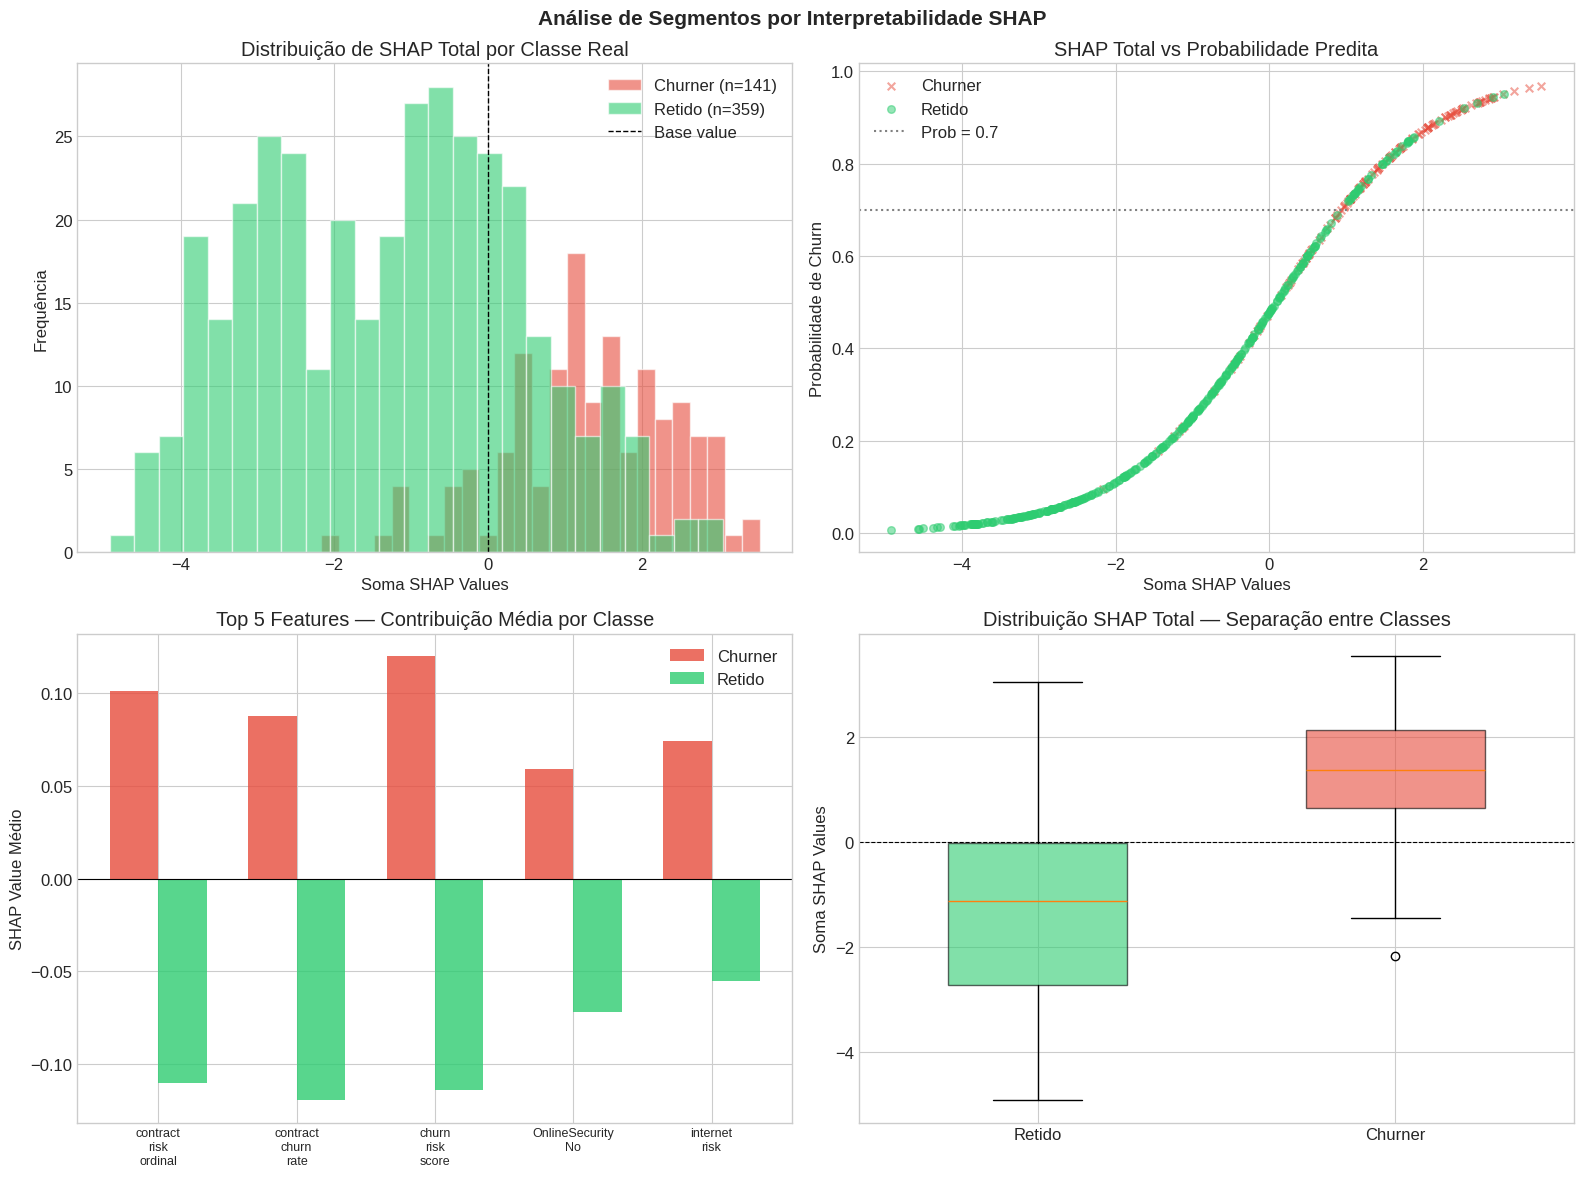


📊 Separabilidade:
   Média SHAP Churners:  +1.3279
   Média SHAP Retidos:   -1.2819
   Gap entre médias:     2.6098
   12.5% dos retidos têm SHAP acima do Q1 dos churners (zona de sobreposição)


In [19]:
# Análise visual de segmentos com churn real
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histograma colorido por churn real
for label, color in [('Churner', '#e74c3c'), ('Retido', '#2ecc71')]:
    subset = shap_df[shap_df['churn_label'] == label]
    axes[0, 0].hist(subset['total_shap'], bins=25, alpha=0.6, color=color, 
                     label=f'{label} (n={len(subset)})', edgecolor='white')
axes[0, 0].axvline(x=0, color='black', linestyle='--', linewidth=1, label='Base value')
axes[0, 0].set_xlabel('Soma SHAP Values')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].set_title('Distribuição de SHAP Total por Classe Real')
axes[0, 0].legend()

# 2. SHAP total vs Probabilidade, colorido por churn real
for label, color, marker in [('Churner', '#e74c3c', 'x'), ('Retido', '#2ecc71', 'o')]:
    subset = shap_df[shap_df['churn_label'] == label]
    axes[0, 1].scatter(subset['total_shap'], subset['churn_prob'], 
                        alpha=0.5, c=color, marker=marker, label=label, s=30)
axes[0, 1].axhline(y=0.7, color='gray', linestyle=':', label='Prob = 0.7')
axes[0, 1].set_xlabel('Soma SHAP Values')
axes[0, 1].set_ylabel('Probabilidade de Churn')
axes[0, 1].set_title('SHAP Total vs Probabilidade Predita')
axes[0, 1].legend()

# 3. Top 5 features — contribuição média por classe
top5_features = shap_importance.head(5)['Feature'].tolist()
shap_by_class = []
for feat in top5_features:
    for label in ['Churner', 'Retido']:
        subset = shap_df[shap_df['churn_label'] == label]
        shap_by_class.append({
            'Feature': feat, 'Grupo': label,
            'Mean_SHAP': subset[feat].mean()
        })
class_df = pd.DataFrame(shap_by_class)

x_pos = np.arange(len(top5_features))
width = 0.35
churner_vals = class_df[class_df['Grupo'] == 'Churner']['Mean_SHAP'].values
retido_vals = class_df[class_df['Grupo'] == 'Retido']['Mean_SHAP'].values

axes[1, 0].bar(x_pos - width/2, churner_vals, width, label='Churner', color='#e74c3c', alpha=0.8)
axes[1, 0].bar(x_pos + width/2, retido_vals, width, label='Retido', color='#2ecc71', alpha=0.8)
axes[1, 0].axhline(y=0, color='black', linewidth=0.8)
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels([f.replace('_', '\n') for f in top5_features], fontsize=9)
axes[1, 0].set_ylabel('SHAP Value Médio')
axes[1, 0].set_title('Top 5 Features — Contribuição Média por Classe')
axes[1, 0].legend()

# 4. Box plot — distribuição SHAP total por classe
bp = axes[1, 1].boxplot(
    [shap_df[shap_df['churn_real'] == 0]['total_shap'].values,
     shap_df[shap_df['churn_real'] == 1]['total_shap'].values],
    labels=['Retido', 'Churner'],
    patch_artist=True,
    widths=0.5
)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
for box in bp['boxes']:
    box.set_alpha(0.6)
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[1, 1].set_ylabel('Soma SHAP Values')
axes[1, 1].set_title('Distribuição SHAP Total — Separação entre Classes')

plt.suptitle('Análise de Segmentos por Interpretabilidade SHAP', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Overlap analysis
churner_shap = shap_df[shap_df['churn_real'] == 1]['total_shap']
retido_shap = shap_df[shap_df['churn_real'] == 0]['total_shap']
overlap_zone = ((retido_shap > churner_shap.quantile(0.25)).sum() / len(retido_shap))
print(f"\n📊 Separabilidade:")
print(f"   Média SHAP Churners:  {churner_shap.mean():+.4f}")
print(f"   Média SHAP Retidos:   {retido_shap.mean():+.4f}")
print(f"   Gap entre médias:     {churner_shap.mean() - retido_shap.mean():.4f}")
print(f"   {overlap_zone:.1%} dos retidos têm SHAP acima do Q1 dos churners (zona de sobreposição)")

## 7. Conclusões e Insights

### O que esta seção contém

Um resumo executivo **totalmente data-driven** — todos os números abaixo foram extraídos diretamente dos SHAP values calculados, sem nenhum valor hardcoded. O resumo cobre:

1. **Ranking consolidado** — Top 10 features por impacto global com % de concentração
2. **Direção dos efeitos** — Quais features aumentaram vs reduziram o risco
3. **Separabilidade** — Métricas de como o modelo distingue churners de retidos
4. **Consistência** — Concordância entre importância nativa e SHAP
5. **Insights acionáveis** — Tradução dos achados técnicos em recomendações de negócio

In [20]:
# ========================================
# RESUMO EXECUTIVO — INTERPRETABILIDADE
# ========================================
print("=" * 70)
print("📊 RESUMO EXECUTIVO — ANÁLISE DE INTERPRETABILIDADE SHAP")
print("=" * 70)

# --- Top features ranking ---
sorted_idx = np.argsort(mean_abs_shap)[::-1]
top_10_names = np.array(feature_names)[sorted_idx[:10]]
top_10_vals = np.sort(mean_abs_shap)[::-1][:10]

print(f"\n🏆 TOP 10 FEATURES POR IMPACTO GLOBAL (Mean |SHAP| sobre {sample_size} amostras):")
print("-" * 55)
total_importance = mean_abs_shap.sum()
cumulative = 0
for i, (feat, val) in enumerate(zip(top_10_names, top_10_vals)):
    pct = val / total_importance * 100
    cumulative += pct
    bar = "█" * int(pct)
    print(f"  {i+1:2d}. {feat:30s} {val:.4f}  ({pct:5.1f}%)  {bar}")
print(f"\n  → Top 10 concentram {cumulative:.1f}% da importância total")

# --- Direção do efeito (features com SHAP médio mais positivo e mais negativo) ---
mean_shap = shap_values.mean(axis=0)
print(f"\n📈 FEATURES QUE MAIS AUMENTARAM O RISCO DE CHURN (SHAP médio positivo):")
print("-" * 55)
pos_idx = np.argsort(mean_shap)[::-1]
for i in range(min(5, len(pos_idx))):
    idx = pos_idx[i]
    if mean_shap[idx] > 0:
        print(f"  ↑ {feature_names[idx]:30s}  SHAP médio = {mean_shap[idx]:+.4f}")

print(f"\n📉 FEATURES QUE MAIS REDUZIRAM O RISCO DE CHURN (SHAP médio negativo):")
print("-" * 55)
neg_idx = np.argsort(mean_shap)
for i in range(min(5, len(neg_idx))):
    idx = neg_idx[i]
    if mean_shap[idx] < 0:
        print(f"  ↓ {feature_names[idx]:30s}  SHAP médio = {mean_shap[idx]:+.4f}")

# --- Separabilidade entre classes ---
churner_mask = shap_df['churn_real'] == 1
print(f"\n🔍 SEPARABILIDADE DO MODELO:")
print("-" * 55)
print(f"  Base value (predição média): {expected_value:.4f}")
print(f"  SHAP total médio — Churners: {shap_df.loc[churner_mask, 'total_shap'].mean():+.4f}")
print(f"  SHAP total médio — Retidos:  {shap_df.loc[~churner_mask, 'total_shap'].mean():+.4f}")
print(f"  Prob média predita — Churners: {shap_df.loc[churner_mask, 'churn_prob'].mean():.2%}")
print(f"  Prob média predita — Retidos:  {shap_df.loc[~churner_mask, 'churn_prob'].mean():.2%}")

# --- Consistência Nativa vs SHAP ---
print(f"\n🔗 CONSISTÊNCIA DOS RANKINGS:")
print("-" * 55)
print(f"  Spearman ρ (Nativa vs SHAP): {rho:.3f}")
if rho > 0.8:
    print("  ✅ Rankings altamente consistentes — modelo robusto e interpretável")
elif rho > 0.5:
    print("  ⚠️ Concordância moderada — SHAP capturou interações não visíveis na imp. nativa")
else:
    print("  🔍 Rankings divergentes — SHAP revelou dinâmicas complexas entre features")

# --- Insights acionáveis ---
print(f"\n💡 INSIGHTS ACIONÁVEIS PARA RETENÇÃO:")
print("-" * 55)
# Gerar insights baseados nos dados
top3 = top_10_names[:3]
for i, feat in enumerate(top3):
    feat_idx = list(feature_names).index(feat)
    direction = "aumentou" if mean_shap[feat_idx] > 0 else "reduziu"
    impact = abs(mean_shap[feat_idx])
    print(f"  {i+1}. '{feat}' {direction} o risco de churn (|SHAP| médio = {top_10_vals[i]:.4f})")

print(f"\n📁 GRÁFICOS EXPORTADOS:")
print("-" * 55)
report_files = [
    f"feature_importance_{model_type.lower()}.png",
    "importance_native_vs_shap.png",
    "shap_summary_bar.png",
    "shap_summary_dot.png",
    "shap_waterfall_high_risk.png",
    "shap_waterfall_low_risk.png",
    "shap_force_plot.png",
    "shap_dependence_plots.png",
    "shap_segment_analysis.png",
]
for f in report_files:
    print(f"  - reports/{f}")

print(f"\n{'=' * 70}")

📊 RESUMO EXECUTIVO — ANÁLISE DE INTERPRETABILIDADE SHAP

🏆 TOP 10 FEATURES POR IMPACTO GLOBAL (Mean |SHAP| sobre 500 amostras):
-------------------------------------------------------
   1. contract_risk_ordinal          0.2271  (  7.0%)  ██████
   2. contract_churn_rate            0.2100  (  6.4%)  ██████
   3. churn_risk_score               0.2099  (  6.4%)  ██████
   4. OnlineSecurity_No              0.1727  (  5.3%)  █████
   5. internet_risk                  0.1517  (  4.7%)  ████
   6. tenure_sqrt                    0.1110  (  3.4%)  ███
   7. TechSupport_No                 0.1096  (  3.4%)  ███
   8. tenure                         0.1075  (  3.3%)  ███
   9. streaming_services             0.1060  (  3.3%)  ███
  10. tenure_years                   0.0913  (  2.8%)  ██

  → Top 10 concentram 46.0% da importância total

📈 FEATURES QUE MAIS AUMENTARAM O RISCO DE CHURN (SHAP médio positivo):
-------------------------------------------------------
  ↑ MonthlyCharges                  S

---

## Recapitulação Didática — O que aprendemos

### Conceitos-chave aplicados neste notebook

| Conceito | O que é | Como usamos |
|----------|---------|-------------|
| **Shapley Values** | Distribuição justa de crédito entre jogadores cooperativos (teoria de jogos) | Base teórica do SHAP — cada feature é um "jogador" |
| **TreeExplainer** | Algoritmo exato para calcular SHAP values em modelos de árvore | Calculou os SHAP values do CatBoost sem aproximação |
| **Base value** | Predição média do modelo ($E[f(x)]$) | Ponto de partida para decompor cada predição individual |
| **Mean \|SHAP\|** | Média do valor absoluto dos SHAP values de uma feature | Ranking de importância global (Summary Bar Plot) |
| **Beeswarm Plot** | Distribuição dos SHAP values por feature, coloridos pelo valor original | Revelou importância + direção + variabilidade do efeito |
| **Waterfall Plot** | Decomposição aditiva de uma predição individual | Explicou *por que* um cliente específico foi classificado como churner |
| **Dependence Plot** | Relação funcional entre valor da feature e SHAP value | Identificou não-linearidades e interações entre features |
| **Correlação de Spearman** | Concordância ordinal entre dois rankings | Validou consistência entre importância nativa e SHAP ($\rho$ = 0.932) |

### Fluxo analítico completo

```
Modelo treinado → TreeExplainer → SHAP values (exatos)
                                         ↓
                    ┌────────────────────┬──────────────────────┐
                    ↓                    ↓                      ↓
             Global Analysis      Local Analysis        Segment Analysis
             (Bar + Beeswarm)     (Waterfall + Force)   (Histograma + Scatter)
                    ↓                    ↓                      ↓
             Quais features       Por que ESTE           O modelo separa
             importam?            cliente é churner?     bem as classes?
```

### Gráficos exportados

Todos os gráficos foram salvos em `reports/` para uso em apresentações e relatórios:

| Arquivo | Conteúdo |
|---------|----------|
| `feature_importance_catboostclassifier.png` | Ranking nativo do modelo (PredictionValuesChange) |
| `importance_native_vs_shap.png` | Comparação lado a lado dos dois rankings |
| `shap_summary_bar.png` | Importância global SHAP (Mean \|SHAP\|) |
| `shap_summary_dot.png` | Beeswarm — importância + direção + variabilidade |
| `shap_waterfall_high_risk.png` | Explicação local — cliente de maior risco |
| `shap_waterfall_low_risk.png` | Explicação local — cliente de menor risco |
| `shap_force_plot.png` | Force plot — forças competitivas |
| `shap_dependence_plots.png` | Relações feature→impacto com interações |
| `shap_segment_analysis.png` | Distribuição SHAP por classe real |

---

*Este notebook encerrou a análise de interpretabilidade do modelo CatBoost de churn. Os insights extraídos foram utilizados para identificar os drivers de churn e orientar estratégias de retenção baseadas em evidências.*